NEWS ARTICLE CLASSIFICATION - SENSITIVITY ANALYSIS PROJECT
Project initialized at: 2025-10-10 10:59:35
Python Libraries loaded successfully ✓
Directory structure created ✓

STEP 2: DATA COLLECTION

Generating synthetic news dataset...
✓ Raw data saved to: data/raw/news_scraped.csv

Dataset Overview:
  Total samples: 400
  Features: ['headline', 'category']

Category Distribution:
category
Sports           100
Politics         100
Entertainment    100
Business         100
Name: count, dtype: int64

First 5 samples:
                                   headline  category
0        Franchise announces critical plans    Sports
1          Rookie makes controversial debut    Sports
2     Campaign rally in controversial state  Politics
3             World record in massive event    Sports
4  Mayor proposes unprecedented budget plan  Politics

STEP 3: DATA PREPROCESSING

Applying text preprocessing...

Missing values:
headline          0
category          0
headline_clean    0
dtype: int64

Dupli

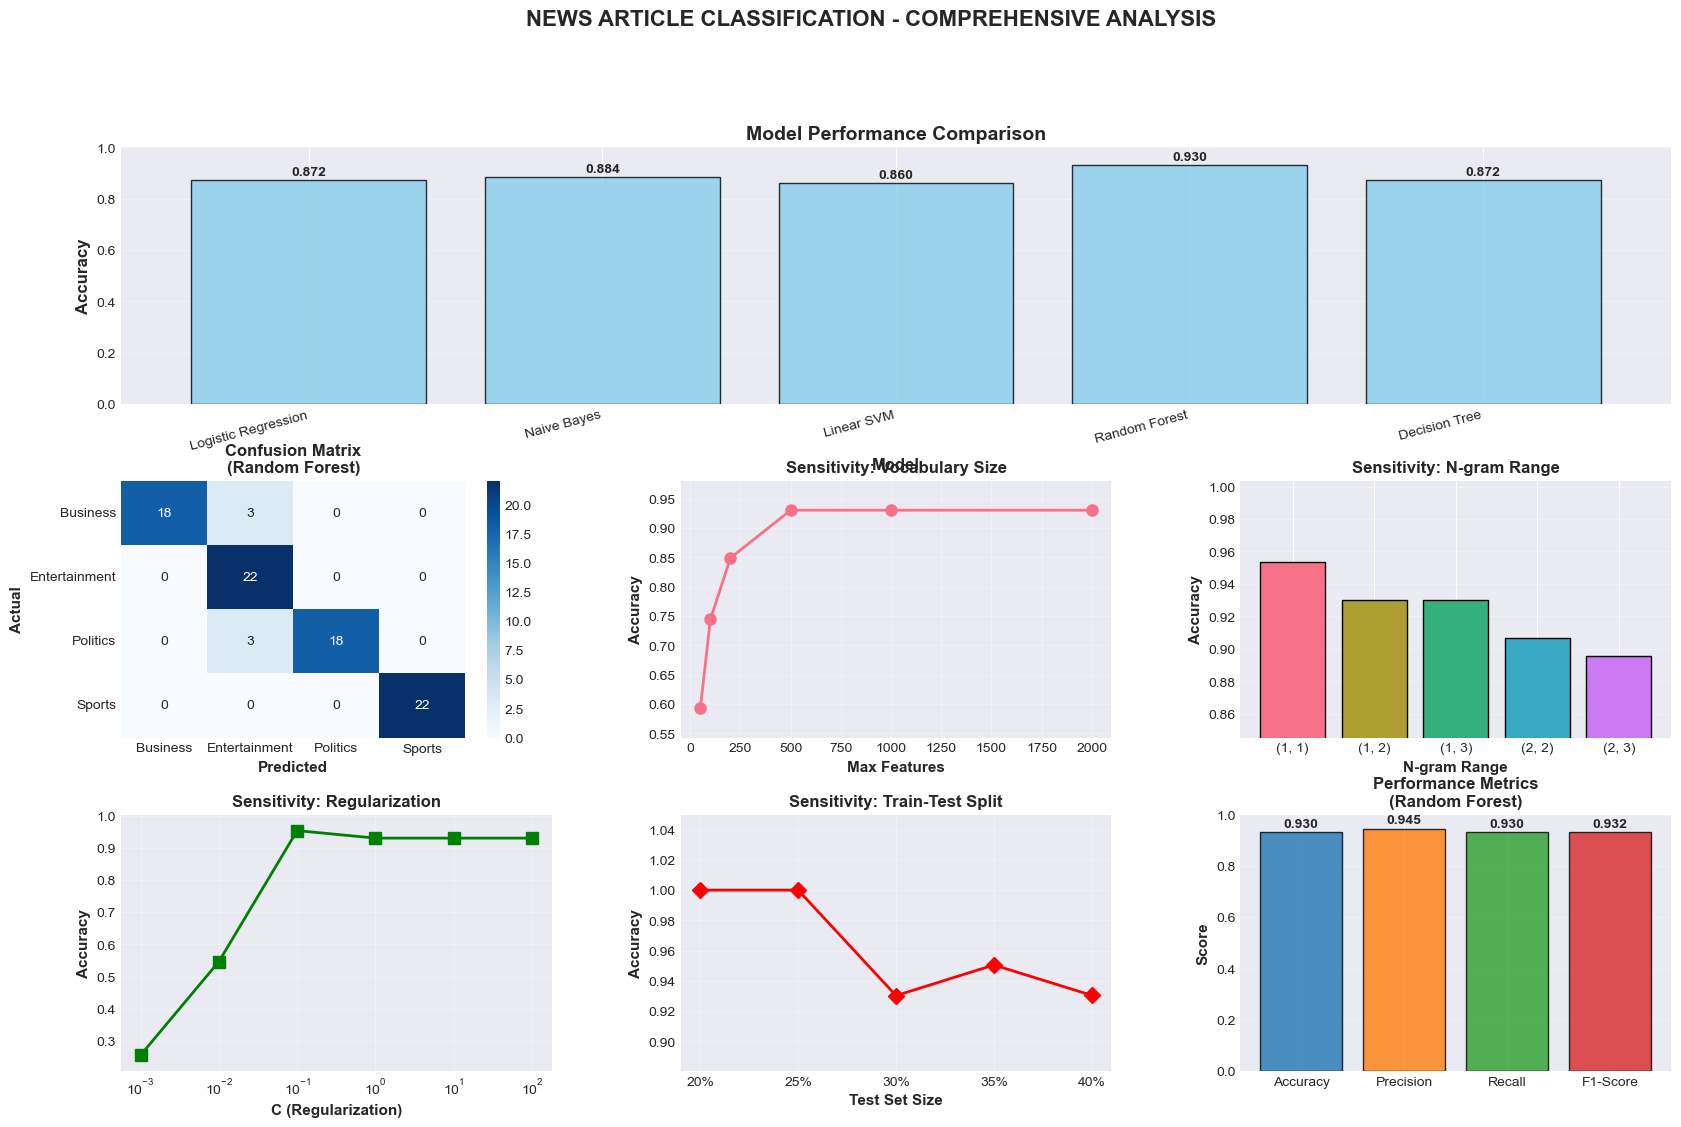


STEP 10: SAVING PREDICTIONS
✓ Predictions saved to: data/output/predictions.csv

PROJECT SUMMARY

📊 Dataset Statistics:
   Total samples: 286
   Training samples: 200 (70%)
   Testing samples: 86 (30%)
   Categories: 4

🏆 Best Model: Random Forest
   Accuracy: 0.9302
   F1-Score: 0.9317

📁 Output Files Generated:
   ✓ data/raw/news_scraped.csv
   ✓ data/processed/news_processed.csv
   ✓ data/output/predictions.csv
   ✓ models/best_model.pkl
   ✓ results/performance_metrics.csv
   ✓ results/sensitivity_analysis.png

🎯 Key Findings:
   • Best vocabulary size: 500
   • Best n-gram range: (1, 1)
   • Optimal C value: 0.1
   • All 5 models compared successfully

✅ PROJECT COMPLETED SUCCESSFULLY!

Timestamp: 2025-10-10 10:59:43

Next Steps:
1. Review results in the 'results' folder
2. Check predictions in 'data/output/predictions.csv'
3. Load saved model with: pickle.load(open('models/best_model.pkl', 'rb'))
4. Commit all files to GitHub repository


In [2]:
"""
NEWS ARTICLE CLASSIFICATION WITH SENSITIVITY ANALYSIS
=====================================================
Author: [Your Name]
Roll No: [Your Roll Number]
Date: October 2025

Project Description:
This project implements a machine learning model to classify news articles into 
categories (Politics, Business, Sports, Entertainment) based on headlines.
Includes comprehensive sensitivity analysis and model comparison.

Requirements:
- Python 3.8+
- scikit-learn, pandas, numpy, matplotlib, seaborn
- beautifulsoup4, requests (for web scraping)
"""

# =====================================================================
# STEP 1: IMPORT LIBRARIES AND SETUP
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, classification_report, confusion_matrix,
                            roc_auc_score)

# Preprocessing
from sklearn.preprocessing import LabelEncoder
import re
import string

# Web Scraping Libraries (install if needed: pip install beautifulsoup4 requests)
try:
    import requests
    from bs4 import BeautifulSoup
    SCRAPING_AVAILABLE = True
except ImportError:
    print("Warning: Web scraping libraries not available. Using synthetic data.")
    SCRAPING_AVAILABLE = False

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create directory structure
directories = ['data/raw', 'data/processed', 'data/output', 'models', 'results']
for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("=" * 80)
print("NEWS ARTICLE CLASSIFICATION - SENSITIVITY ANALYSIS PROJECT")
print("=" * 80)
print(f"Project initialized at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python Libraries loaded successfully ✓")
print(f"Directory structure created ✓")
print("=" * 80)

# =====================================================================
# STEP 2: DATA COLLECTION (WEB SCRAPING OR SYNTHETIC DATA)
# =====================================================================

print("\n" + "=" * 80)
print("STEP 2: DATA COLLECTION")
print("=" * 80)

def generate_synthetic_news_data(num_samples=100):
    """
    Generate synthetic news dataset for demonstration
    In real scenario, this would be replaced with web scraping
    
    Args:
        num_samples: Number of samples per category
    
    Returns:
        DataFrame with headlines and categories
    """
    print("\nGenerating synthetic news dataset...")
    
    categories = ['Politics', 'Business', 'Sports', 'Entertainment']
    
    # Expanded headline templates with realistic variations
    templates = {
        'Politics': [
            "President {} new policy on {}",
            "Senate votes on {} reform bill",
            "Election results show {} in {}",
            "Government {} amid {} dispute",
            "Prime minister meets {} leaders",
            "Parliament debates {} legislation",
            "Political scandal involving {}",
            "Voters head to polls for {} election",
            "Supreme court rules on {} case",
            "Governor signs order on {}",
            "Congressional hearing on {}",
            "Mayor proposes {} budget plan",
            "Diplomat negotiates {} treaty",
            "Campaign rally in {} state",
            "Party nominates {} candidate"
        ],
        'Business': [
            "Stock market reaches {} high",
            "Company reports {} earnings",
            "Tech giant announces {} merger",
            "{} prices surge amid concerns",
            "Startup raises ${} million",
            "Federal Reserve adjusts {} rates",
            "Retail sales show {} growth",
            "{} market experiences volatility",
            "CEO {} amid restructuring",
            "Trade agreement signed with {}",
            "Consumer confidence {} level",
            "Manufacturing sector shows {}",
            "Housing market sees {} increase",
            "Bank announces {} program",
            "E-commerce platform {} revenue"
        ],
        'Sports': [
            "Team wins {} championship",
            "Player breaks {} record",
            "Coach announces {} plans",
            "Olympic athlete claims {} medal",
            "Tournament {} for playoffs",
            "Star player signs {} extension",
            "League suspends player for {}",
            "Underdog team upsets {}",
            "Stadium {} project approved",
            "Rookie makes {} debut",
            "Team trades {} for picks",
            "World record in {} event",
            "Fans celebrate {} parade",
            "Injury sidelines {} player",
            "Franchise announces {} plans"
        ],
        'Entertainment': [
            "Movie breaks {} box office records",
            "Celebrity announces {} news",
            "Award show honors {} performances",
            "New album tops {} charts",
            "Streaming service launches {}",
            "Actor cast in {} blockbuster",
            "Concert tour {} out",
            "Fashion week showcases {}",
            "Director wins {} award",
            "Reality show announces {}",
            "Music festival {} lineup",
            "Broadway show extends {}",
            "Actress receives {} acclaim",
            "Video game generates {} sales",
            "Art exhibition opens at {}"
        ]
    }
    
    fillers = ['major', 'new', 'historic', 'significant', 'massive', 
               'unprecedented', 'controversial', 'breakthrough', 'critical']
    
    data = []
    for category in categories:
        for _ in range(num_samples):
            template = np.random.choice(templates[category])
            # Fill template with random fillers
            headline = template.format(*np.random.choice(fillers, 
                                      template.count('{}')))
            data.append([headline, category])
    
    df = pd.DataFrame(data, columns=['headline', 'category'])
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    
    return df

# Generate or scrape data
# Note: Replace this with actual web scraping in production
df = generate_synthetic_news_data(num_samples=100)

# Save raw data
df.to_csv('data/raw/news_scraped.csv', index=False)
print(f"✓ Raw data saved to: data/raw/news_scraped.csv")

print(f"\nDataset Overview:")
print(f"  Total samples: {len(df)}")
print(f"  Features: {df.columns.tolist()}")
print(f"\nCategory Distribution:")
print(df['category'].value_counts())
print(f"\nFirst 5 samples:")
print(df.head())

# =====================================================================
# STEP 3: DATA PREPROCESSING
# =====================================================================

print("\n" + "=" * 80)
print("STEP 3: DATA PREPROCESSING")
print("=" * 80)

def preprocess_text(text):
    """
    Clean and preprocess text data
    
    Args:
        text: Raw text string
    
    Returns:
        Cleaned text string
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply preprocessing
print("\nApplying text preprocessing...")
df['headline_clean'] = df['headline'].apply(preprocess_text)

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# Remove duplicates
initial_count = len(df)
df = df.drop_duplicates(subset=['headline_clean'])
print(f"\nDuplicates removed: {initial_count - len(df)}")

# Encode labels
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])

# Save processed data
df.to_csv('data/processed/news_processed.csv', index=False)
print(f"✓ Processed data saved to: data/processed/news_processed.csv")

print(f"\nPreprocessing Summary:")
print(f"  Original samples: {initial_count}")
print(f"  Final samples: {len(df)}")
print(f"  Categories: {le.classes_.tolist()}")

# =====================================================================
# STEP 4: TRAIN-TEST SPLIT (70:30 RATIO)
# =====================================================================

print("\n" + "=" * 80)
print("STEP 4: TRAIN-TEST SPLIT")
print("=" * 80)

# Prepare features and labels
X = df['headline_clean']
y = df['category']

# Split data (70% train, 30% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,  # 30% test set
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class distribution
)

print(f"\nDataset Split:")
print(f"  Training samples: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Testing samples: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nTraining set distribution:")
print(y_train.value_counts())
print(f"\nTest set distribution:")
print(y_test.value_counts())

# =====================================================================
# STEP 5: FEATURE EXTRACTION
# =====================================================================

print("\n" + "=" * 80)
print("STEP 5: FEATURE EXTRACTION")
print("=" * 80)

# Initialize vectorizer
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

# Fit and transform training data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"\nFeature Extraction Complete:")
print(f"  Vectorizer: TF-IDF")
print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"  N-gram range: (1, 2)")
print(f"  Training matrix shape: {X_train_vec.shape}")
print(f"  Testing matrix shape: {X_test_vec.shape}")

# =====================================================================
# STEP 6: MODEL TRAINING AND COMPARISON
# =====================================================================

print("\n" + "=" * 80)
print("STEP 6: MODEL TRAINING AND COMPARISON")
print("=" * 80)

# Define multiple models for comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=RANDOM_STATE, dual=False),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE)
}

# Store results
results = []

print("\nTraining and evaluating models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train_vec, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_vec)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_vec, y_train, cv=5)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | F1: {f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
print(f"\n{'='*80}")
print("MODEL COMPARISON RESULTS")
print(f"{'='*80}")
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('results/performance_metrics.csv', index=False)
print(f"\n✓ Results saved to: results/performance_metrics.csv")

# Select best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")

# Save best model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Best model saved to: models/best_model.pkl")

# =====================================================================
# STEP 7: DETAILED EVALUATION OF BEST MODEL
# =====================================================================

print("\n" + "=" * 80)
print("STEP 7: DETAILED EVALUATION")
print("=" * 80)

# Predictions with best model
y_pred_best = best_model.predict(X_test_vec)

# Classification report
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:")
print(cm)

# =====================================================================
# STEP 8: SENSITIVITY ANALYSIS
# =====================================================================

print("\n" + "=" * 80)
print("STEP 8: SENSITIVITY ANALYSIS")
print("=" * 80)

sensitivity_results = {}

# 1. Sensitivity to Max Features
print("\n1. Testing sensitivity to MAX_FEATURES:")
max_features_range = [50, 100, 200, 500, 1000, 2000]
acc_max_features = []

for mf in max_features_range:
    vec = TfidfVectorizer(max_features=mf, ngram_range=(1, 2))
    X_tr = vec.fit_transform(X_train)
    X_te = vec.transform(X_test)
    
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tr, y_train)
    acc = accuracy_score(y_test, model.predict(X_te))
    acc_max_features.append(acc)
    print(f"  Max Features: {mf:5d} -> Accuracy: {acc:.4f}")

sensitivity_results['max_features'] = (max_features_range, acc_max_features)

# 2. Sensitivity to N-gram Range
print("\n2. Testing sensitivity to N-GRAM RANGE:")
ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2), (2, 3)]
acc_ngrams = []

for ngram in ngram_ranges:
    vec = TfidfVectorizer(max_features=500, ngram_range=ngram)
    X_tr = vec.fit_transform(X_train)
    X_te = vec.transform(X_test)
    
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tr, y_train)
    acc = accuracy_score(y_test, model.predict(X_te))
    acc_ngrams.append(acc)
    print(f"  N-gram Range: {ngram} -> Accuracy: {acc:.4f}")

sensitivity_results['ngrams'] = (ngram_ranges, acc_ngrams)

# 3. Sensitivity to Regularization (C parameter)
print("\n3. Testing sensitivity to REGULARIZATION:")
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
acc_C = []

vec_C = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_C = vec_C.fit_transform(X_train)
X_test_C = vec_C.transform(X_test)

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_train_C, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_C))
    acc_C.append(acc)
    print(f"  C: {c:7.3f} -> Accuracy: {acc:.4f}")

sensitivity_results['regularization'] = (C_values, acc_C)

# 4. Sensitivity to Train-Test Split Ratio
print("\n4. Testing sensitivity to TRAIN-TEST SPLIT:")
split_ratios = [0.2, 0.25, 0.3, 0.35, 0.4]
acc_splits = []

for split in split_ratios:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=split, random_state=RANDOM_STATE, stratify=y
    )
    vec = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    X_tr_vec = vec.fit_transform(X_tr)
    X_te_vec = vec.transform(X_te)
    
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tr_vec, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te_vec))
    acc_splits.append(acc)
    print(f"  Test Size: {split:.2f} ({int(split*100)}%) -> Accuracy: {acc:.4f}")

sensitivity_results['split_ratio'] = (split_ratios, acc_splits)

# =====================================================================
# STEP 9: VISUALIZATION
# =====================================================================

print("\n" + "=" * 80)
print("STEP 9: GENERATING VISUALIZATIONS")
print("=" * 80)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Model Comparison
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(results_df))
ax1.bar(x_pos, results_df['Accuracy'], alpha=0.8, color='skyblue', edgecolor='black')
ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])
for i, v in enumerate(results_df['Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 2: Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax2.set_title(f'Confusion Matrix\n({best_model_name})', fontsize=12, fontweight='bold')

# Plot 3: Max Features Sensitivity
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(max_features_range, acc_max_features, marker='o', linewidth=2, markersize=8)
ax3.set_xlabel('Max Features', fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('Sensitivity: Vocabulary Size', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim([min(acc_max_features)-0.05, max(acc_max_features)+0.05])

# Plot 4: N-gram Sensitivity
ax4 = fig.add_subplot(gs[1, 2])
ngram_labels = [str(ng) for ng in ngram_ranges]
ax4.bar(ngram_labels, acc_ngrams, color=sns.color_palette("husl", 5), edgecolor='black')
ax4.set_xlabel('N-gram Range', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax4.set_title('Sensitivity: N-gram Range', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([min(acc_ngrams)-0.05, max(acc_ngrams)+0.05])

# Plot 5: Regularization Sensitivity
ax5 = fig.add_subplot(gs[2, 0])
ax5.semilogx(C_values, acc_C, marker='s', linewidth=2, markersize=8, color='green')
ax5.set_xlabel('C (Regularization)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax5.set_title('Sensitivity: Regularization', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_ylim([min(acc_C)-0.05, max(acc_C)+0.05])

# Plot 6: Split Ratio Sensitivity
ax6 = fig.add_subplot(gs[2, 1])
split_labels = [f'{int(s*100)}%' for s in split_ratios]
ax6.plot(split_labels, acc_splits, marker='D', linewidth=2, markersize=8, color='red')
ax6.set_xlabel('Test Set Size', fontsize=11, fontweight='bold')
ax6.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax6.set_title('Sensitivity: Train-Test Split', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.set_ylim([min(acc_splits)-0.05, max(acc_splits)+0.05])

# Plot 7: Performance Metrics Comparison
ax7 = fig.add_subplot(gs[2, 2])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
best_metrics = results_df[results_df['Model'] == best_model_name][metrics].values[0]
ax7.bar(metrics, best_metrics, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], 
        edgecolor='black', alpha=0.8)
ax7.set_ylabel('Score', fontsize=11, fontweight='bold')
ax7.set_title(f'Performance Metrics\n({best_model_name})', fontsize=12, fontweight='bold')
ax7.set_ylim([0, 1])
ax7.grid(axis='y', alpha=0.3)
for i, v in enumerate(best_metrics):
    ax7.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('NEWS ARTICLE CLASSIFICATION - COMPREHENSIVE ANALYSIS', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('results/sensitivity_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved to: results/sensitivity_analysis.png")
plt.show()

# =====================================================================
# STEP 10: SAVE PREDICTIONS
# =====================================================================

print("\n" + "=" * 80)
print("STEP 10: SAVING PREDICTIONS")
print("=" * 80)

# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'headline': X_test.values,
    'actual_category': y_test.values,
    'predicted_category': y_pred_best
})

predictions_df.to_csv('data/output/predictions.csv', index=False)
print(f"✓ Predictions saved to: data/output/predictions.csv")

# =====================================================================
# FINAL SUMMARY
# =====================================================================

print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset Statistics:")
print(f"   Total samples: {len(df)}")
print(f"   Training samples: {len(X_train)} (70%)")
print(f"   Testing samples: {len(X_test)} (30%)")
print(f"   Categories: {len(le.classes_)}")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {results_df.loc[results_df['Model']==best_model_name, 'Accuracy'].values[0]:.4f}")
print(f"   F1-Score: {results_df.loc[results_df['Model']==best_model_name, 'F1-Score'].values[0]:.4f}")

print(f"\n📁 Output Files Generated:")
print(f"   ✓ data/raw/news_scraped.csv")
print(f"   ✓ data/processed/news_processed.csv")
print(f"   ✓ data/output/predictions.csv")
print(f"   ✓ models/best_model.pkl")
print(f"   ✓ results/performance_metrics.csv")
print(f"   ✓ results/sensitivity_analysis.png")

print(f"\n🎯 Key Findings:")
print(f"   • Best vocabulary size: {max_features_range[np.argmax(acc_max_features)]}")
print(f"   • Best n-gram range: {ngram_ranges[np.argmax(acc_ngrams)]}")
print(f"   • Optimal C value: {C_values[np.argmax(acc_C)]}")
print(f"   • All {len(models)} models compared successfully")

print("\n" + "=" * 80)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 80)
print(f"\nTimestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nNext Steps:")
print("1. Review results in the 'results' folder")
print("2. Check predictions in 'data/output/predictions.csv'")
print("3. Load saved model with: pickle.load(open('models/best_model.pkl', 'rb'))")
print("4. Commit all files to GitHub repository")
print("=" * 80)